# Capítulo 8 — Satélites e Radar: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | órbitas: período, velocidade e cobertura vs. altitude | NumPy |
| 2 | funções peso: o sondador de 6 canais | NumPy |
| 3 | $Z$–$R$: inversão da chuva e suas incertezas | NumPy |
| 4 | aliasing Doppler: dobrar e desdobrar velocidades | NumPy |

Para dados **reais**: `Py-ART` (radar) e `Satpy` (satélite) estão instalados no ambiente — bons projetos de equipe.

Exercícios numéricos N1–N4 no fim; soluções em `cap08_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

GM = 3.986e14      # m3/s2
R_T = 6.371e6      # m
c_luz = 3.0e8      # m/s

## Caso 1 — Órbitas: Newton escolhe a altitude

$$T = 2\pi\sqrt{\frac{r^3}{GM}}\qquad\text{(3ª lei de Kepler)}$$

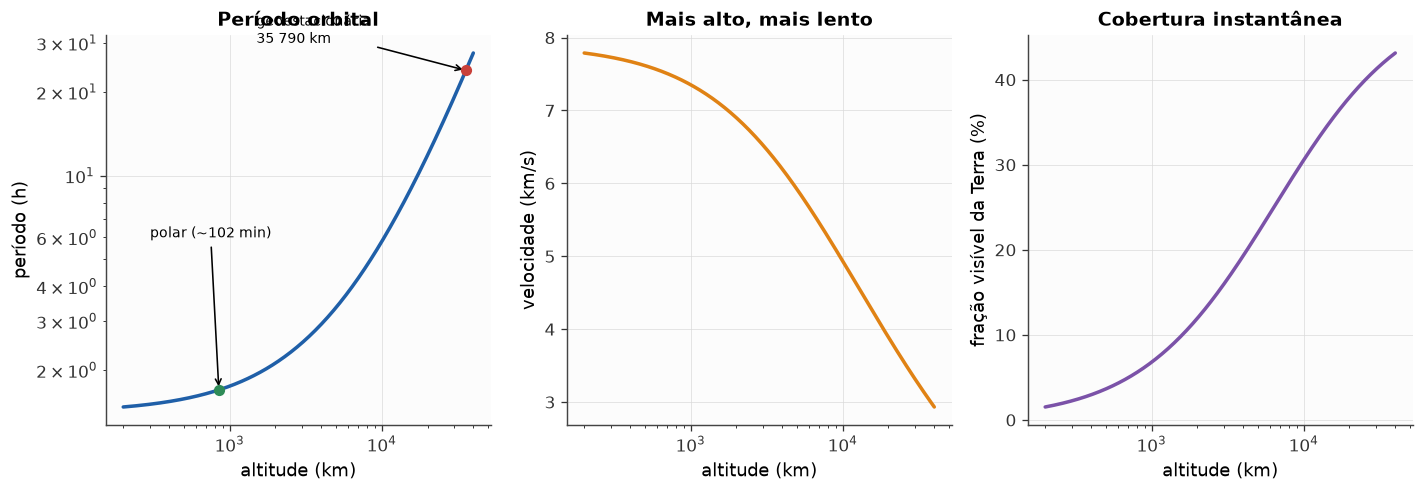

geoestacionária: z = 35793 km | polar 850 km: T = 102 min | disco visível do geo: 42% da esfera


In [2]:
z = np.logspace(np.log10(200e3), np.log10(40000e3), 400)
r = R_T + z
T_h = 2*np.pi*np.sqrt(r**3/GM)/3600
v_kms = np.sqrt(GM/r)/1e3
frac_visivel = 0.5*(1 - R_T/r)          # fração da esfera visível

T_sid = 86164.0
r_geo = (GM*T_sid**2/(4*np.pi**2))**(1/3)
z_geo = r_geo - R_T

fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.4))
axs[0].loglog(z/1e3, T_h, color=CORES['azul'])
axs[0].scatter([z_geo/1e3], [23.93], color=CORES['vermelho'], zorder=5)
axs[0].annotate('geoestacionária\n35 790 km', xy=(z_geo/1e3, 23.9),
                xytext=(1500, 30), fontsize=9,
                arrowprops=dict(arrowstyle='->', lw=1))
axs[0].scatter([850], [1.7], color=CORES['verde'], zorder=5)
axs[0].annotate('polar (~102 min)', xy=(850, 1.7), xytext=(300, 6),
                fontsize=9, arrowprops=dict(arrowstyle='->', lw=1))
axs[0].set(xlabel='altitude (km)', ylabel='período (h)', title='Período orbital')
axs[1].semilogx(z/1e3, v_kms, color=CORES['laranja'])
axs[1].set(xlabel='altitude (km)', ylabel='velocidade (km/s)',
           title='Mais alto, mais lento')
axs[2].semilogx(z/1e3, 100*frac_visivel, color=CORES['roxo'])
axs[2].set(xlabel='altitude (km)', ylabel='fração visível da Terra (%)',
           title='Cobertura instantânea')
fig.tight_layout(); plt.show()
print(f'geoestacionária: z = {z_geo/1e3:.0f} km | '
      f'polar 850 km: T = {2*np.pi*np.sqrt((R_T+850e3)**3/GM)/60:.0f} min | '
      f'disco visível do geo: {100*0.5*(1-R_T/r_geo):.0f}% da esfera')

## Caso 2 — Funções peso: o sondador vertical

$$\tau(z) = \exp\!\Big[-\!\int_z^\infty k\rho\,dz'\Big],\qquad W(z) = \frac{d\tau}{dz} = k\rho(z)\,\tau(z)$$

Com $\rho = \rho_0 e^{-z/H}$: canais com $k$ maior enxergam mais alto. Seis canais = seis alturas = um perfil.

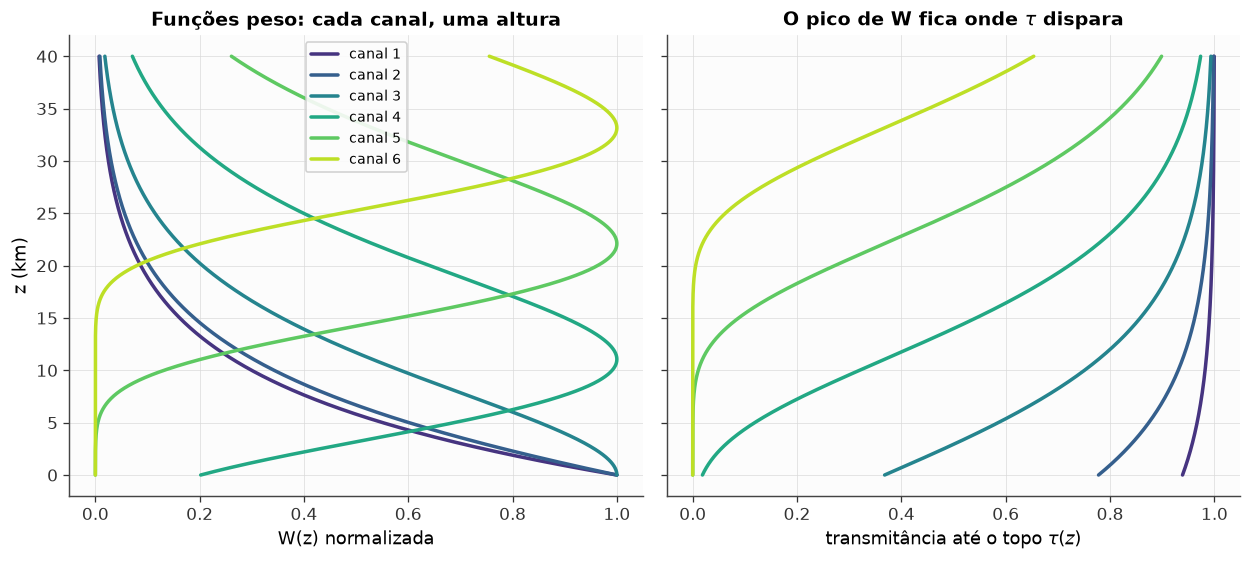

picos dos canais (km): [ 0.   0.   0.  11.1 22.1 33.1]
teoria: pico em z = H·ln(kρ0H) → canal 6: 33.2 km ✓


In [3]:
H, rho0 = 8.0e3, 1.2
z = np.linspace(0, 40e3, 800)

def W_peso(k):
    tau = np.exp(-k*rho0*H*np.exp(-z/H))
    return k*rho0*np.exp(-z/H)*tau, tau

ks = np.logspace(-1.2, 1.8, 6)/(rho0*H)     # 6 canais
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(ks)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
picos = []
for i, (k, cor) in enumerate(zip(ks, cmap)):
    W, tau = W_peso(k)
    ax1.plot(W/W.max(), z/1e3, color=cor, label=f'canal {i+1}')
    picos.append(z[np.argmax(W)]/1e3)
    ax2.plot(tau, z/1e3, color=cor)
ax1.set(xlabel='W(z) normalizada', ylabel='z (km)',
        title='Funções peso: cada canal, uma altura')
ax1.legend(fontsize=8.5)
ax2.set(xlabel='transmitância até o topo $\\tau(z)$',
        title='O pico de W fica onde $\\tau$ dispara')
fig.tight_layout(); plt.show()

print('picos dos canais (km):', np.round(picos, 1))
print(f'teoria: pico em z = H·ln(kρ0H) → canal 6: '
      f'{H*np.log(ks[-1]*rho0*H)/1e3:.1f} km ✓')

## Caso 3 — $Z$–$R$: quanta chuva há naquele eco?

$$Z = a\,R^b \;\Rightarrow\; R = (Z/a)^{1/b}$$

Duas relações clássicas discordam — e a calibração de $\pm$2–3 dB piora tudo. Por isso acumulados de radar são sempre ajustados com pluviômetros.

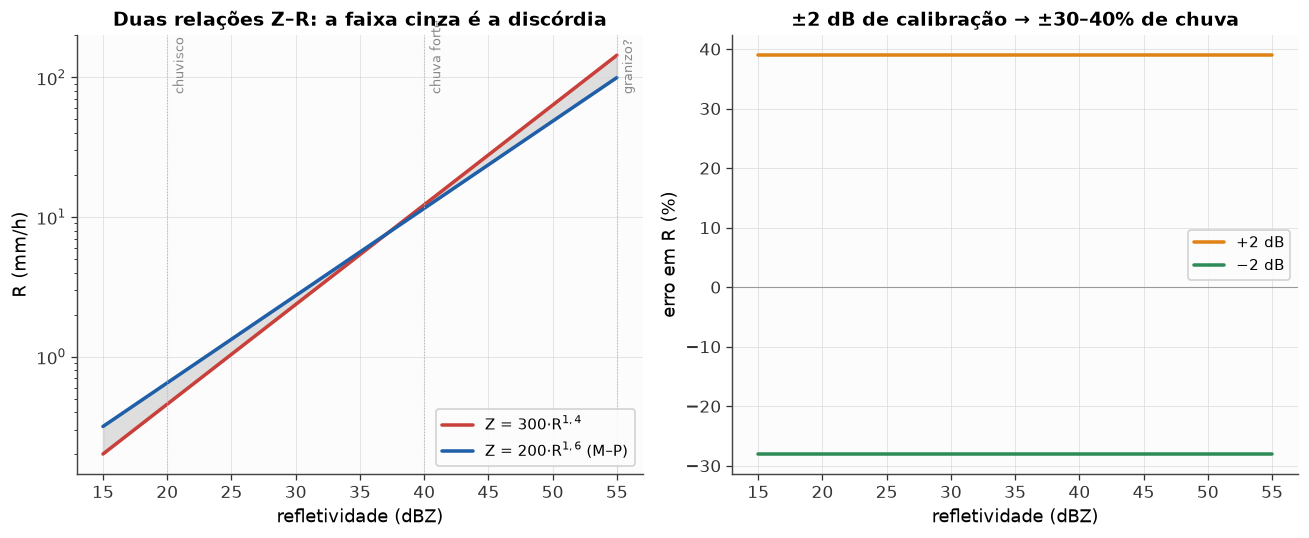

40 dBZ → 12 mm/h (convectiva) | 12 mm/h (M–P)


In [4]:
dBZ = np.linspace(15, 55, 300)
Z = 10**(dBZ/10)
R_conv = (Z/300.0)**(1/1.4)      # convectiva (NWS)
R_MP   = (Z/200.0)**(1/1.6)      # Marshall–Palmer

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax1.semilogy(dBZ, R_conv, color=CORES['vermelho'], label='Z = 300·R$^{1,4}$')
ax1.semilogy(dBZ, R_MP, color=CORES['azul'], label='Z = 200·R$^{1,6}$ (M–P)')
ax1.fill_between(dBZ, R_conv, R_MP, color=CORES['cinza'], alpha=0.2)
for d, nome in [(20, 'chuvisco'), (40, 'chuva forte'), (55, 'granizo?')]:
    ax1.axvline(d, color='#bbbbbb', lw=0.7, ls=':')
    ax1.text(d+0.4, 80, nome, rotation=90, fontsize=8, color='#888888')
ax1.set(xlabel='refletividade (dBZ)', ylabel='R (mm/h)',
        title='Duas relações Z–R: a faixa cinza é a discórdia')
ax1.legend()

# propagação do erro de calibração ±2 dB
erro_dB = 2.0
R_alto = ((Z*10**(erro_dB/10))/300.0)**(1/1.4)
R_baixo = ((Z*10**(-erro_dB/10))/300.0)**(1/1.4)
ax2.plot(dBZ, 100*(R_alto/R_conv - 1), color=CORES['laranja'],
         label=f'+{erro_dB:.0f} dB')
ax2.plot(dBZ, 100*(R_baixo/R_conv - 1), color=CORES['verde'],
         label=f'−{erro_dB:.0f} dB')
ax2.axhline(0, color='#999999', lw=0.7)
ax2.set(xlabel='refletividade (dBZ)', ylabel='erro em R (%)',
        title='±2 dB de calibração → ±30–40% de chuva')
ax2.legend()
fig.tight_layout(); plt.show()
print(f'40 dBZ → {np.interp(40, dBZ, R_conv):.0f} mm/h (convectiva) | '
      f'{np.interp(40, dBZ, R_MP):.0f} mm/h (M–P)')

## Caso 4 — O dilema do Doppler e o aliasing

$$R_{max}V_{max} = \frac{c\,\lambda}{8}$$

Velocidades além de $V_{max}$ **dobram** para dentro do intervalo $[-V_{max}, +V_{max}]$. Vamos dobrar um campo de vento sintético e tentar desdobrá-lo por continuidade.

banda S (10 cm): Rmax·Vmax = cλ/8 = 3750 km·(m/s)
banda C (5 cm): Rmax·Vmax = cλ/8 = 1875 km·(m/s)
banda X (3 cm): Rmax·Vmax = cλ/8 = 1125 km·(m/s)


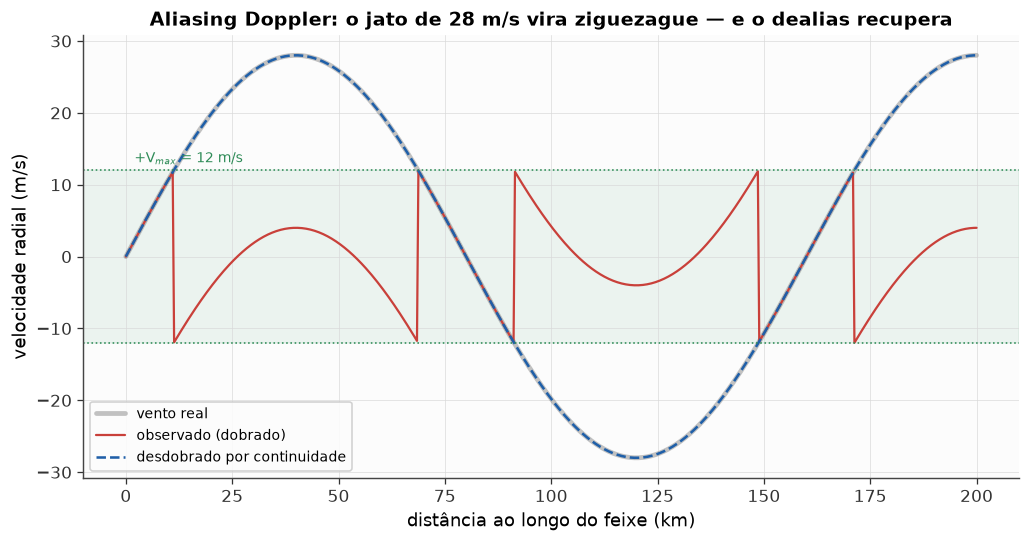

erro máximo após dealias: 0.00 m/s


In [5]:
lam_radar = 0.05                     # banda C: 5 cm
for banda, lamb in [('S (10 cm)', 0.10), ('C (5 cm)', 0.05), ('X (3 cm)', 0.03)]:
    print(f'banda {banda}: Rmax·Vmax = cλ/8 = {c_luz*lamb/8/1e3:.0f} km·(m/s)')

Vmax = 12.0                          # m/s (PRF baixa p/ alcance longo)
x = np.linspace(0, 200, 600)         # km ao longo do feixe
V_real = 28*np.sin(2*np.pi*x/160)    # jato de 28 m/s: |V| > Vmax!
V_obs = (V_real + Vmax) % (2*Vmax) - Vmax    # dobrado

# dealias por continuidade
V_fix = V_obs.copy()
for i in range(1, len(V_fix)):
    while V_fix[i] - V_fix[i-1] > Vmax:
        V_fix[i] -= 2*Vmax
    while V_fix[i] - V_fix[i-1] < -Vmax:
        V_fix[i] += 2*Vmax

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.plot(x, V_real, color=CORES['cinza'], lw=3, alpha=0.4, label='vento real')
ax.plot(x, V_obs, color=CORES['vermelho'], lw=1.4,
        label='observado (dobrado)')
ax.plot(x, V_fix, '--', color=CORES['azul'], lw=1.6,
        label='desdobrado por continuidade')
ax.axhspan(-Vmax, Vmax, color=CORES['verde'], alpha=0.08)
ax.axhline(Vmax, color=CORES['verde'], ls=':', lw=1)
ax.axhline(-Vmax, color=CORES['verde'], ls=':', lw=1)
ax.text(2, Vmax+1, f'+V$_{{max}}$ = {Vmax:.0f} m/s', fontsize=8.5,
        color=CORES['verde'])
ax.set(xlabel='distância ao longo do feixe (km)',
       ylabel='velocidade radial (m/s)',
       title='Aliasing Doppler: o jato de 28 m/s vira ziguezague — e o dealias recupera')
ax.legend(loc='lower left', fontsize=9)
plt.show()
print(f'erro máximo após dealias: {np.max(np.abs(V_fix - V_real)):.2f} m/s')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap08_solucoes.ipynb`**.

**N1** — Acrescente ao Caso 1 o tempo que o satélite polar leva para revisitar o mesmo ponto do equador (considere a rotação da Terra sob a órbita) e o número de órbitas por dia.

**N2** — No sondador do Caso 2, substitua o perfil exponencial por um com o dobro de absorvedor acima de 20 km ("camada de ozônio") e veja como os picos dos canais altos migram.

**N3** — Monte um acumulado de 1 h: série sintética de dBZ com células convectivas passando; integre $R(t)$ com as duas relações Z–R e compare os acumulados com e sem ruído de ±2 dB.

**N4** — Quebre o dealias do Caso 4: aumente a amplitude do jato até o método de continuidade falhar; identifique o critério de falha (salto real > $V_{max}$ entre pontos vizinhos).

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*